[Point(1, 1), Point(10, 1), Point(10, 10), Point(1, 10)]


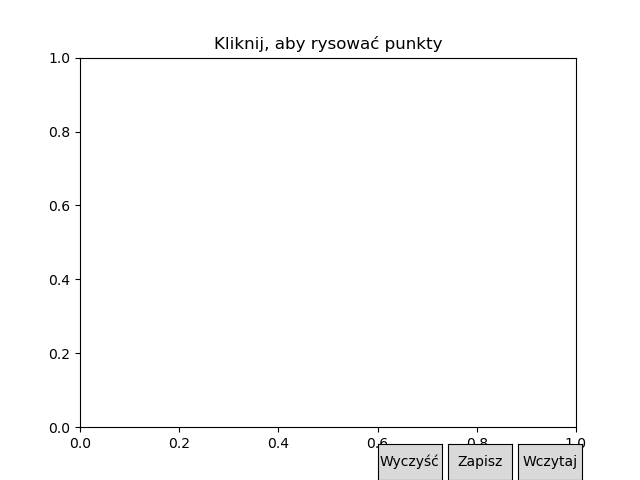

[Point(0.3585937407708938, 0.01981872294372297), Point(0.8142389020612164, 0.08745941558441561), Point(0.8747227730289583, 0.3553165584415585), Point(0.9110130956096035, 0.7990395021645023), Point(0.5299647085128293, 0.9613771645021645), Point(0.11665825689992601, 0.8639745670995671), Point(0.015851805287022763, 0.3066152597402597), Point(0.10456148270637758, 0.07393127705627708)]


In [1]:
%run interface.ipynb
%run tests.ipynb
%run graham.ipynb
import math

In [79]:
def divide_all_points(points, m):
    n = len(points)
    r = math.ceil(n / m)
    l = n // m # tyle będzie grup liczących m punktów
    k = n % m # tyle punktów będzie w ostatniej grupie
    new_groups = [[] for _ in range(r)]

    for i in range(l):
        for j in range(m):
            new_groups[i].append(points[i * m + j])

    for i in range(k):
        new_groups[-1].append(points[l * m + i])

    return new_groups

In [80]:
def find_lowest_point(hulls):
    min_y_point = hulls[0][0] # aktualny najmniejszy punkt
    k, l = 0, 0 # indeks otoczki oraz punktu w otoczce
    for i in range(len(hulls)):
        for j in range(len(hulls[i])):
            if hulls[i][j].y < min_y_point.y:
                min_y_point = hulls[i][j]
                k, l = i, j
    
    return k, l

In [81]:
def set_angle(u, v):
    """
    Funkcja do wyznaczenia kąta wyznaczanego przez wektory u i v
    :param u: krotka (xu, yu) opisująca wektor u
    :param v: krotka (xv, yv) opisująca wektor v
    :return: kąt wyznaczany przez wektory u i v
    """
    if v == (0, 0):
        return math.inf
    u_len = (u[0]**2 + u[1]**2)**0.5
    v_len = (v[0]**2 + v[1]**2)**0.5
    u_v_scalar = u[0] * v[0] + u[1] * v[1]
    u_v_cos = (int((u_v_scalar / (u_len * v_len)) * 10**12)) / 10**12
    angle = (int(np.arccos(u_v_cos) * 10**12)) / 10**12
    return angle

In [82]:
def get_points_vector(point1, point2):
    """
    point1: ostatni punkt w finalnej otoczce
    point2: rozpatrywany punkt do finalnej otoczki
    """
    x_delta = point2.x - point1.x
    y_delta = point2.y - point1.y
    return (x_delta, y_delta)

In [83]:
def points_distance(point1, point2):
    """
    point1: ostatni punkt w finalnej otoczce
    point2: rozpatrywany punkt do finalnej otoczki
    """
    x_delta = point2.x - point1.x
    y_delta = point2.y - point1.y
    return (x_delta**2 + y_delta**2)**0.5

In [84]:
def find_max_angle_point(hull, point, last_vector):
    n = len(hull)
    left = 0
    right = n - 1

    if n == 1:
        return hull[0], set_angle(last_vector, get_points_vector(point, hull[0]))

    if n == 2:
        first_point = hull[0]
        last_point = hull[1]

        first_point_angle = set_angle(last_vector, get_points_vector(point, first_point))
        last_point_angle = set_angle(last_vector, get_points_vector(point, last_point))

        if first_point_angle < last_point_angle or (first_point_angle == last_point_angle and points_distance(point, last_point) < points_distance(point, first_point)):
            return first_point, first_point_angle
        if last_point_angle < first_point_angle or (first_point_angle == last_point_angle and points_distance(point, first_point) < points_distance(point, last_point)):
            return last_point, last_point_angle

    while left < right:
        mid = (left + right) // 2
        left_mid = (mid - 1 + n) % n
        right_mid = (mid + 1) % n

        if hull[left_mid] == point:
            left_mid = (left_mid - 1 + n) % n
        if hull[right_mid] == point:
            right_mid = (right_mid + 1) % n

        mid_point = hull[mid]
        left_point = hull[left]
        right_point = hull[right]
        left_mid_point = hull[left_mid]
        right_mid_point = hull[right_mid]

        mid_point_angle = set_angle(last_vector, get_points_vector(point, mid_point))
        left_point_angle = set_angle(last_vector, get_points_vector(point, left_point))
        right_point_angle = set_angle(last_vector, get_points_vector(point, right_point))
        left_mid_point_angle = set_angle(last_vector, get_points_vector(point, left_mid_point))
        right_mid_point_angle = set_angle(last_vector, get_points_vector(point, right_mid_point))

        final_left_angle = left_point_angle
        final_left_point = left_point
        if left_mid_point_angle < left_point_angle or (left_mid_point_angle == left_point_angle and points_distance(point, left_point) < points_distance(point, left_mid_point)):
            final_left_angle = left_mid_point_angle
            final_left_point = left_mid_point

        final_right_angle = right_point_angle
        final_right_point = right_point
        if right_mid_point_angle < right_point_angle or (right_mid_point_angle == right_point_angle and points_distance(point, right_point) < points_distance(point, right_mid_point)):
            final_right_angle = right_mid_point_angle
            final_right_point = right_mid_point

        if mid_point_angle < final_left_angle and mid_point_angle < final_right_angle:
            return hull[mid], mid_point_angle
        elif final_right_angle < final_left_angle or (final_right_angle == final_left_angle and points_distance(point, final_right_point) < points_distance(point, final_left_point)): 
            left = mid + 1
        elif final_left_angle < final_right_angle or (final_left_angle == final_right_angle and points_distance(point, final_left_point) < points_distance(point, final_right_point)):
            right = mid - 1
            
    return hull[left], set_angle(last_vector, get_points_vector(point, hull[left]))

In [90]:
def PartialHull(points, m):
    divided_points = divide_all_points(points, m)
    n = len(points)
    r = math.ceil(n / m)
    hulls = []
    for new_set_points in divided_points:
        hulls.append((graham_algorithm(new_set_points)))
    hull_nr, i = find_lowest_point(hulls)
    p1 = hulls[hull_nr][i]
    final_hull = [p1]
    last_vector = (1.0, 0.0)
    for k in range(m):
        min_angle = math.inf
        min_angle_point = None
        for i in range(r):
            q, q_angle = find_max_angle_point(hulls[i], final_hull[-1], last_vector)
            if q_angle < min_angle or (q_angle == min_angle and points_distance(final_hull[-1], q) > points_distance(final_hull[-1], min_angle_point)):
                min_angle = q_angle
                min_angle_point = q
        if min_angle_point == p1:
            return final_hull
        else:
            final_hull.append(min_angle_point)
            last_vector = (final_hull[-1].x - final_hull[-2].x, final_hull[-1].y - final_hull[-2].y)
    return [] # za małe m

In [91]:
def chan(points):
    t = 1
    n = len(points)
    while True:
        m = min(2**t, n)
        L = PartialHull(points, m)
        if len(L) != 0: # znaleziono otoczkę (L jest listą pustą kiedy m jest za małe)
            return L
        t += 1

In [92]:
def chan_with_m(points, m):
    L = PartialHull(points, m)
    if len(L) != 0: # znaleziono otoczkę (L jest listą pustą kiedy m jest za małe)
        return L
    return "Podana ilość wierzchołków otoczki jest za mała"


In [93]:
points = test1
print(chan(points))

[Point(1, 1), Point(10, 1), Point(10, 10), Point(1, 10)]


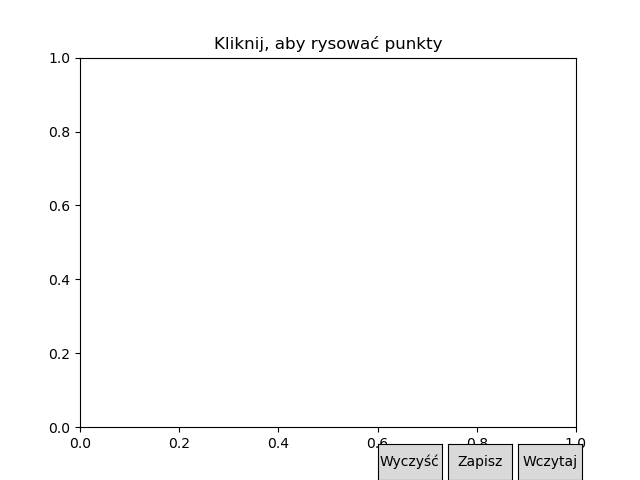

In [95]:
PolygonDrawer()

In [96]:
with open('points.json') as f:
    points = json.load(f)
points = [Point(x, y) for x, y in points]
print(chan(points))

[Point(0.8848034181902485, 0.04958062770562774), Point(0.9493195472225068, 0.3336715367965368), Point(0.8888356762547648, 0.9126758658008658), Point(0.16706148270637758, 0.9451433982683983), Point(0.017867934319280826, 0.8125676406926408), Point(0.05819051496444211, 0.2146239177489178), Point(0.19730341819024858, 0.07122564935064937)]
